# BBF304E — 10-Year CHD Risk Prediction
**Dataset:** Framingham Heart Study  
**Models:** Logistic Regression, Decision Tree, Random Forest  
**Dataset:** https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression

## 1. Setup

In [1]:
# install dependencies if not already present
%pip install -q numpy pandas matplotlib seaborn scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# imports and global random seed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report, precision_recall_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load Dataset

In [3]:
# dataset must be in the same folder as this notebook
# source: https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression
# place framingham.csv in the same folder as this notebook
df = pd.read_csv('framingham.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (4238, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 3. Exploratory Data Analysis
Overview of data types, missing values, distributions and class balance.

In [4]:
# quick overview of data types and summary statistics
print(df.dtypes)
df.describe()

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [5]:
# glucose column has the most missing values at ~9%
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df[missing_df['Missing'] > 0]

,Missing,Percent
education,105,2.48
cigsPerDay,29,0.68
BPMeds,53,1.25
totChol,50,1.18
BMI,19,0.45
heartRate,1,0.02
glucose,388,9.16


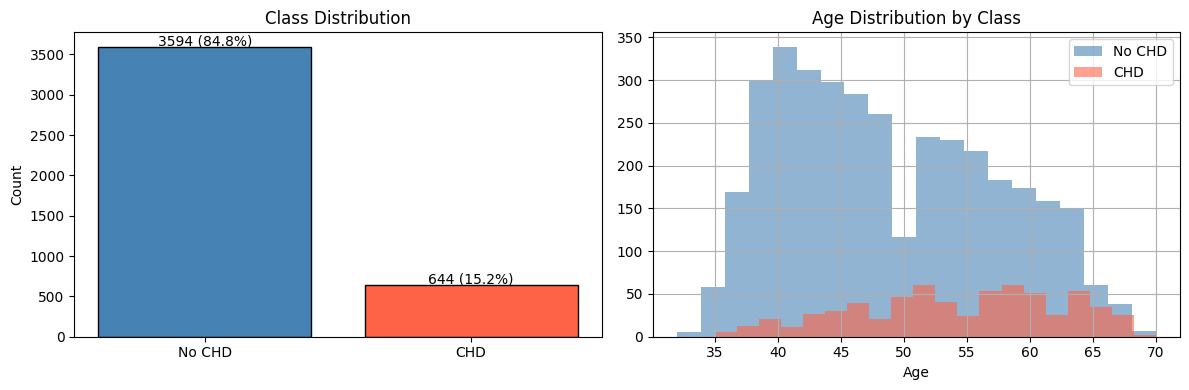

In [6]:
# class is imbalanced: ~85% negative, ~15% positive
target_counts = df['TenYearCHD'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No CHD', 'CHD'], target_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, f'{v} ({v/len(df)*100:.1f}%)', ha='center')

df[df['TenYearCHD']==0]['age'].hist(ax=axes[1], alpha=0.6, bins=20,
    color='steelblue', label='No CHD')
df[df['TenYearCHD']==1]['age'].hist(ax=axes[1], alpha=0.6, bins=20,
    color='tomato', label='CHD')
axes[1].set_title('Age Distribution by Class')
axes[1].set_xlabel('Age')
axes[1].legend()
plt.tight_layout()
plt.savefig('eda_class_age.png', dpi=150, bbox_inches='tight')
plt.show()

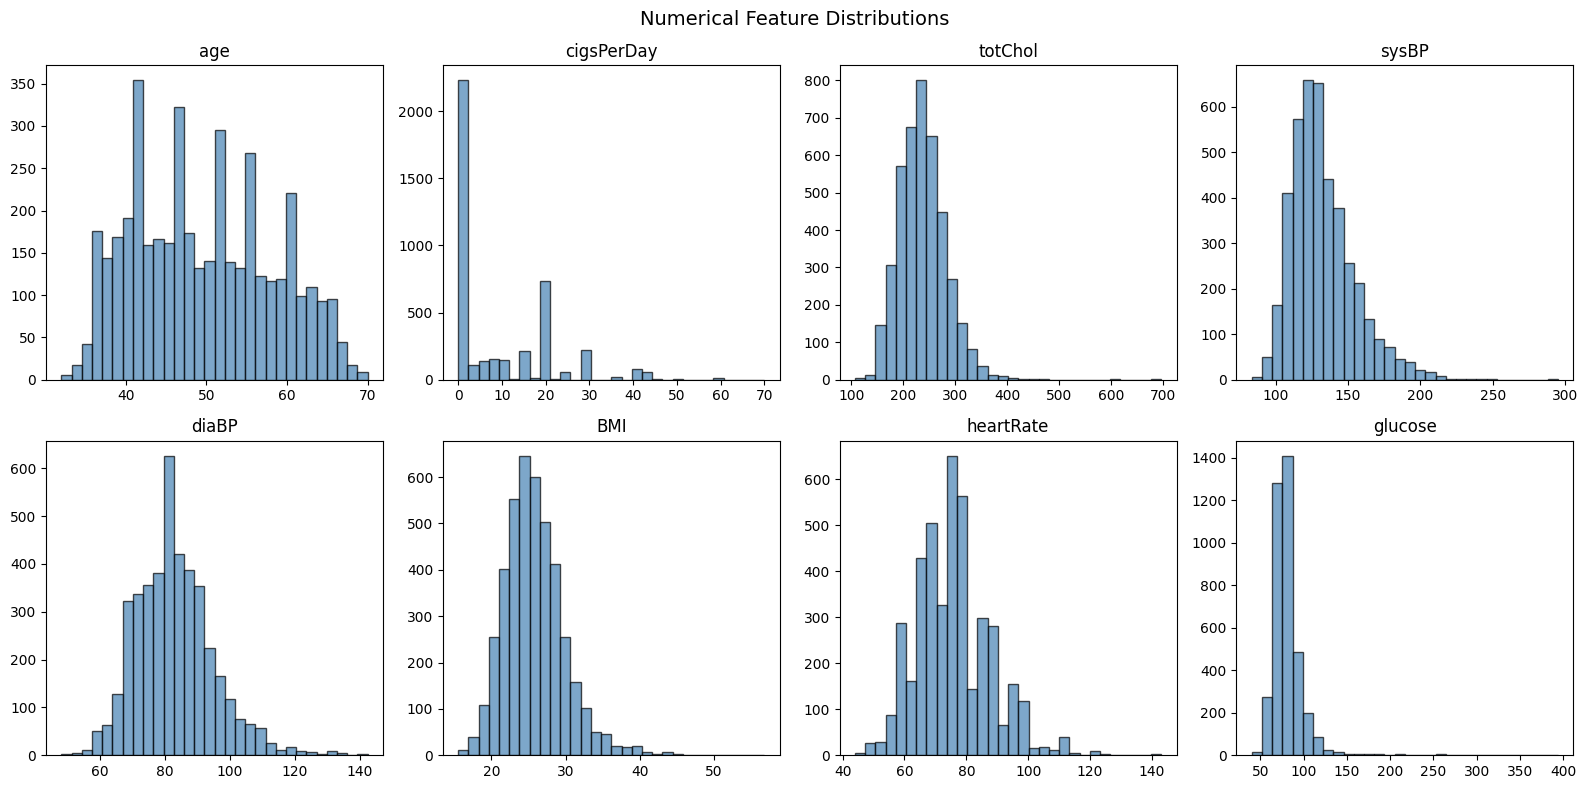

In [7]:
# check for skewed distributions and outliers
numerical_cols = ['age','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('eda_feature_dist.png', dpi=150, bbox_inches='tight')
plt.show()

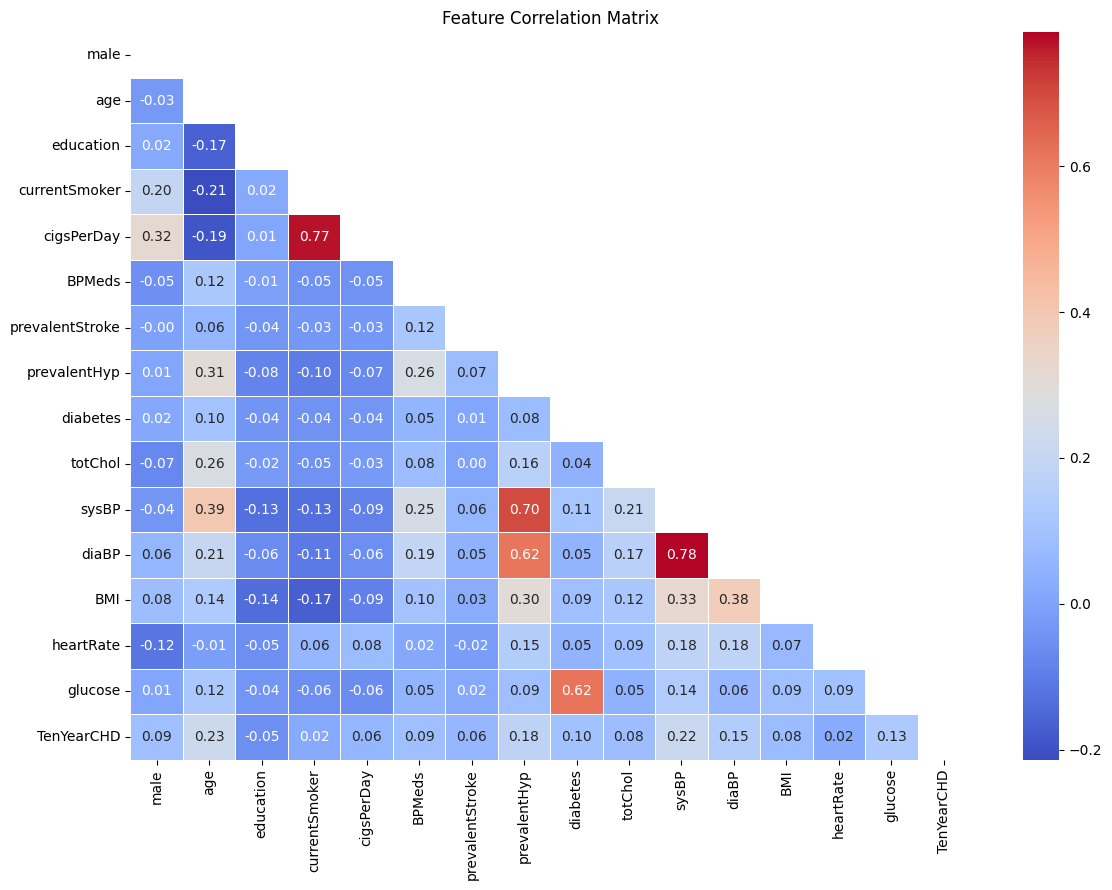

In [8]:
# sysBP and diaBP are strongly correlated as expected
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# CHD patients tend to be older with higher blood pressure
df.groupby('TenYearCHD')[numerical_cols].mean()

,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
TenYearCHD,,,,,,,,
0,48.767668,8.710401,235.172530,130.333612,82.160963,25.673007,75.762382,80.682125
1,54.145963,10.629283,245.388976,143.618789,86.981366,26.531451,76.530327,89.008418


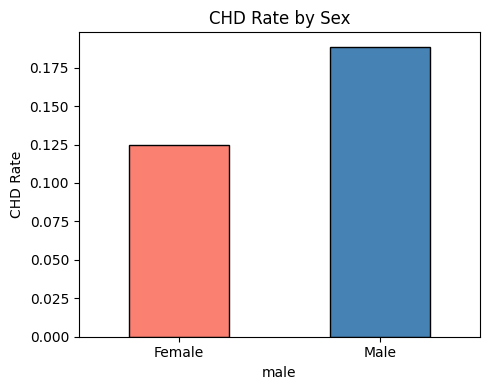

In [10]:
# males have a higher CHD rate than females
chd_by_sex = df.groupby('male')['TenYearCHD'].mean().rename({0:'Female', 1:'Male'})
chd_by_sex.plot(kind='bar', color=['salmon','steelblue'], edgecolor='black', figsize=(5,4))
plt.title('CHD Rate by Sex')
plt.ylabel('CHD Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_sex_chd.png', dpi=150, bbox_inches='tight')
plt.show()

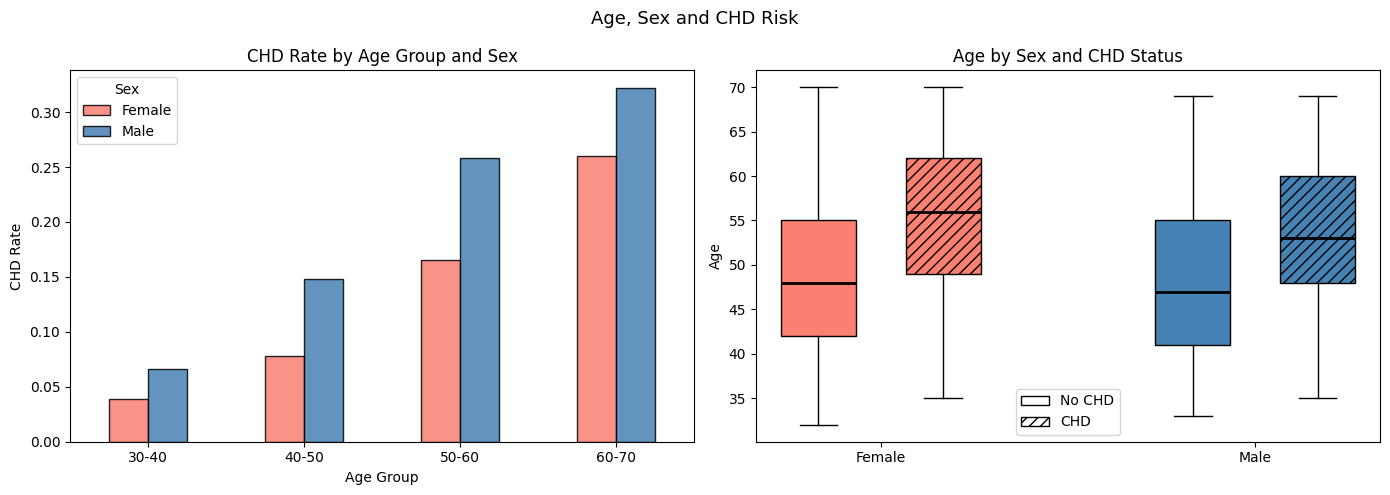

In [11]:
# CHD risk increases with age in both sexes
import matplotlib.patches as mpatches
df_plot = df.copy()
df_plot['age_group'] = pd.cut(df_plot['age'], bins=[30,40,50,60,70],
                               labels=['30-40','40-50','50-60','60-70'])
df_plot['sex'] = df_plot['male'].map({0:'Female', 1:'Male'})
chd_age_sex = df_plot.groupby(['age_group','sex'])['TenYearCHD'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
chd_age_sex.plot(kind='bar', ax=axes[0], color=['salmon','steelblue'],
    edgecolor='black', alpha=0.85)
axes[0].set_title('CHD Rate by Age Group and Sex')
axes[0].set_ylabel('CHD Rate')
axes[0].set_xlabel('Age Group')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sex')

groups = [
    df_plot[(df_plot['male']==0)&(df_plot['TenYearCHD']==0)]['age'],
    df_plot[(df_plot['male']==0)&(df_plot['TenYearCHD']==1)]['age'],
    df_plot[(df_plot['male']==1)&(df_plot['TenYearCHD']==0)]['age'],
    df_plot[(df_plot['male']==1)&(df_plot['TenYearCHD']==1)]['age'],
]
bp = axes[1].boxplot(groups, positions=[1,2,4,5], patch_artist=True,
    widths=0.6, medianprops=dict(color='black', linewidth=2))
for patch, color, hatch in zip(bp['boxes'],
    ['salmon','salmon','steelblue','steelblue'], ['','///','','///']):
    patch.set_facecolor(color); patch.set_hatch(hatch)
axes[1].set_xticks([1.5, 4.5])
axes[1].set_xticklabels(['Female','Male'])
axes[1].set_title('Age by Sex and CHD Status')
axes[1].set_ylabel('Age')
no_chd_p = mpatches.Patch(facecolor='white', edgecolor='black', label='No CHD')
chd_p = mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label='CHD')
axes[1].legend(handles=[no_chd_p, chd_p])
plt.suptitle('Age, Sex and CHD Risk', fontsize=13)
plt.tight_layout()
plt.savefig('eda_age_sex_chd.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing
Duplicate removal, missing value imputation, train/test split and feature scaling.

In [12]:
# drop duplicates, then separate features from target
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df)} duplicate rows')

X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']
feature_names = X.columns.tolist()
print(f'Features: {feature_names}')
print(f'Class distribution: {y.value_counts().to_dict()}')

Removed 0 duplicate rows
Features: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
Class distribution: {0: 3594, 1: 644}


In [13]:
# median imputation keeps all rows and is our primary strategy
# Strategy 1: median for numerical, mode for categorical
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

imputer_median = SimpleImputer(strategy='median')
X_imputed = X.copy()
X_imputed[num_cols] = imputer_median.fit_transform(X[num_cols])
if cat_cols:
    imputer_mode = SimpleImputer(strategy='most_frequent')
    X_imputed[cat_cols] = imputer_mode.fit_transform(X[cat_cols])
print(f'Missing values after imputation: {X_imputed.isnull().sum().sum()}')

Missing values after imputation: 0


In [14]:
# listwise deletion used only for the ablation comparison
# Strategy 2: drop rows with any missing value
df_complete = df.dropna()
X_listwise = df_complete.drop('TenYearCHD', axis=1)
y_listwise = df_complete['TenYearCHD']
print(f'Listwise deletion: {len(df_complete)} rows kept, {len(df)-len(df_complete)} dropped')

Listwise deletion: 3656 rows kept, 582 dropped


In [15]:
# stratified split preserves the 85/15 class ratio in both sets
# scaler is fit on train only to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test positive rate: {y_test.mean():.3f}')

Train: (3390, 15) | Test: (848, 15)
Train positive rate: 0.152
Test positive rate: 0.152


## 5. Model Training & Hyperparameter Tuning
Grid search with 5-fold CV. class_weight=balanced addresses the class imbalance.

In [16]:
# C controls regularization strength for LR
# max_depth limits tree size to reduce overfitting
# adjust these grids to try different hyperparameter ranges
LR_PARAM_GRID = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
DT_PARAM_GRID = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
RF_PARAM_GRID = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5]
}
CV_FOLDS = 5
SCORING = 'roc_auc'

In [17]:
# L1 vs L2 regularization comparison included in the grid
print('Tuning Logistic Regression...')
t0 = time.time()
lr_cv = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    LR_PARAM_GRID, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1
)
lr_cv.fit(X_train_scaled, y_train)
lr_train_time = time.time() - t0
best_lr = lr_cv.best_estimator_
print(f'Best params: {lr_cv.best_params_}')
print(f'CV ROC-AUC: {lr_cv.best_score_:.4f} | Train time: {lr_train_time:.2f}s')

Tuning Logistic Regression...
Best params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
CV ROC-AUC: 0.7310 | Train time: 2.38s


In [18]:
# gini and entropy splitting criteria both tested
print('Tuning Decision Tree...')
t0 = time.time()
dt_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    DT_PARAM_GRID, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1
)
dt_cv.fit(X_train_scaled, y_train)
dt_train_time = time.time() - t0
best_dt = dt_cv.best_estimator_
print(f'Best params: {dt_cv.best_params_}')
print(f'CV ROC-AUC: {dt_cv.best_score_:.4f} | Train time: {dt_train_time:.2f}s')

Tuning Decision Tree...
Best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
CV ROC-AUC: 0.6858 | Train time: 0.42s


In [19]:
# RF trains multiple trees on bootstrap samples
print('Tuning Random Forest...')
t0 = time.time()
rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    RF_PARAM_GRID, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1
)
rf_cv.fit(X_train_scaled, y_train)
rf_train_time = time.time() - t0
best_rf = rf_cv.best_estimator_
print(f'Best params: {rf_cv.best_params_}')
print(f'CV ROC-AUC: {rf_cv.best_score_:.4f} | Train time: {rf_train_time:.2f}s')

Tuning Random Forest...
Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
CV ROC-AUC: 0.7153 | Train time: 5.57s


## 6. Evaluation
Test set metrics, confusion matrices, ROC curves, threshold tuning and error analysis.

In [20]:
# evaluate all three models on the held-out test set
models = {
    'Logistic Regression': best_lr,
    'Decision Tree': best_dt,
    'Random Forest': best_rf
}
train_times = {
    'Logistic Regression': lr_train_time,
    'Decision Tree': dt_train_time,
    'Random Forest': rf_train_time
}

results = []
inference_times = {}
for name, model in models.items():
    t0 = time.time()
    y_pred = model.predict(X_test_scaled)
    inference_times[name] = (time.time() - t0) * 1000
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Train Time (s)': round(train_times[name], 2),
        'Inference Time (ms)': round(inference_times[name], 2)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s),Inference Time (ms)
Model,,,,,,,
Logistic Regression,0.6592,0.2436,0.5891,0.3447,0.6990,2.38,1.45
Decision Tree,0.5955,0.2139,0.6202,0.3181,0.6411,0.42,0.47
Random Forest,0.6910,0.2432,0.4884,0.3247,0.6815,5.57,9.45


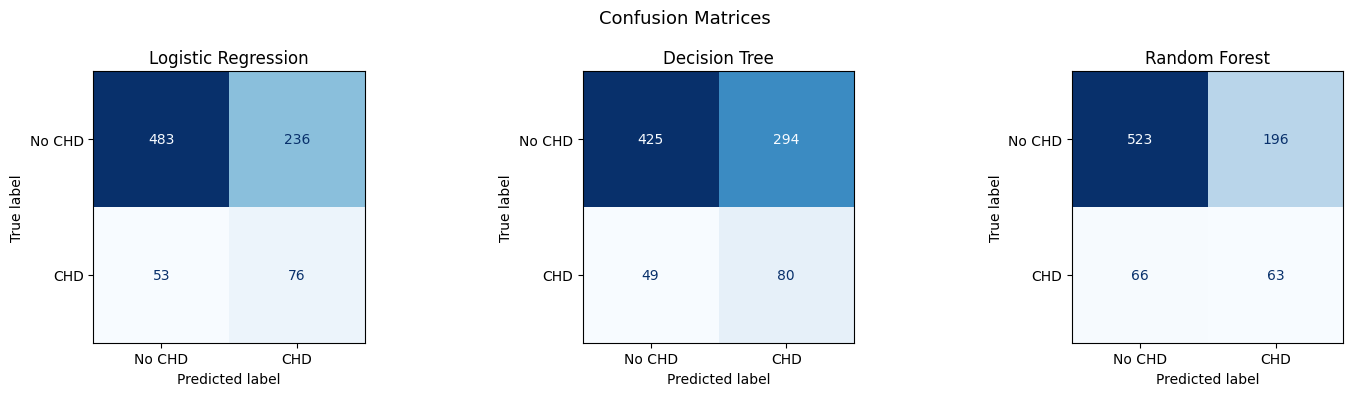

In [21]:
# rows are actual labels, columns are predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    ConfusionMatrixDisplay(cm, display_labels=['No CHD','CHD']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

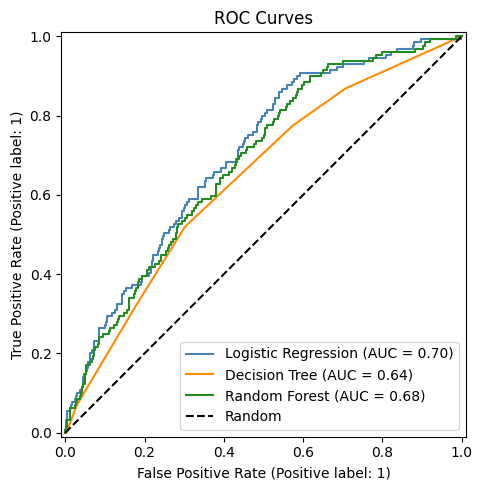

In [22]:
# higher AUC means better separation between classes
fig, ax = plt.subplots(figsize=(7, 5))
for (name, model), color in zip(models.items(), ['steelblue','darkorange','forestgreen']):
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test,
        ax=ax, name=name, color=color)
ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
for name, model in models.items():
    print(f'\n--- {name} ---')
    print(classification_report(y_test, model.predict(X_test_scaled),
                                target_names=['No CHD','CHD']))


--- Logistic Regression ---
              precision    recall  f1-score   support

      No CHD       0.90      0.67      0.77       719
         CHD       0.24      0.59      0.34       129

    accuracy                           0.66       848
   macro avg       0.57      0.63      0.56       848
weighted avg       0.80      0.66      0.71       848


--- Decision Tree ---
              precision    recall  f1-score   support

      No CHD       0.90      0.59      0.71       719
         CHD       0.21      0.62      0.32       129

    accuracy                           0.60       848
   macro avg       0.56      0.61      0.52       848
weighted avg       0.79      0.60      0.65       848


--- Random Forest ---
              precision    recall  f1-score   support

      No CHD       0.89      0.73      0.80       719
         CHD       0.24      0.49      0.32       129

    accuracy                           0.69       848
   macro avg       0.57      0.61      0.56       848

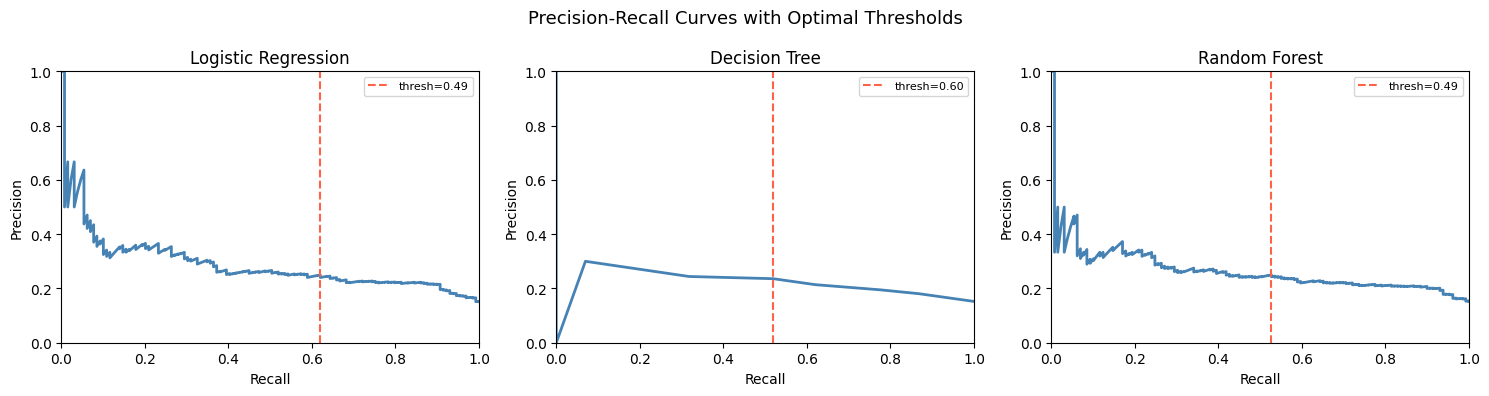

,Optimal Threshold,F1 default,F1 optimal,Recall default,Recall optimal
Model,,,,,
Logistic Regression,0.493,0.3447,0.3556,0.5891,0.6202
Decision Tree,0.601,0.3181,0.3245,0.6202,0.5194
Random Forest,0.494,0.3247,0.3392,0.4884,0.5271


In [24]:
# default 0.5 threshold is not optimal for imbalanced data
# we find the threshold that maximizes F1 score
# find the probability threshold that maximizes F1 for each model
threshold_results = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores[:-1])
    best_thresh = thresholds[best_idx]
    y_pred_opt = (y_prob >= best_thresh).astype(int)

    threshold_results.append({
        'Model': name,
        'Optimal Threshold': round(best_thresh, 3),
        'F1 default': round(f1_score(y_test, model.predict(X_test_scaled), zero_division=0), 4),
        'F1 optimal': round(f1_score(y_test, y_pred_opt, zero_division=0), 4),
        'Recall default': round(recall_score(y_test, model.predict(X_test_scaled), zero_division=0), 4),
        'Recall optimal': round(recall_score(y_test, y_pred_opt, zero_division=0), 4),
    })

    ax.plot(recalls, precisions, color='steelblue', lw=2)
    ax.axvline(recalls[best_idx], color='tomato', linestyle='--',
               label=f'thresh={best_thresh:.2f}')
    ax.set_title(f'{name}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=8)
    ax.set_xlim([0,1]); ax.set_ylim([0,1])

plt.suptitle('Precision-Recall Curves with Optimal Thresholds', fontsize=13)
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
pd.DataFrame(threshold_results).set_index('Model')

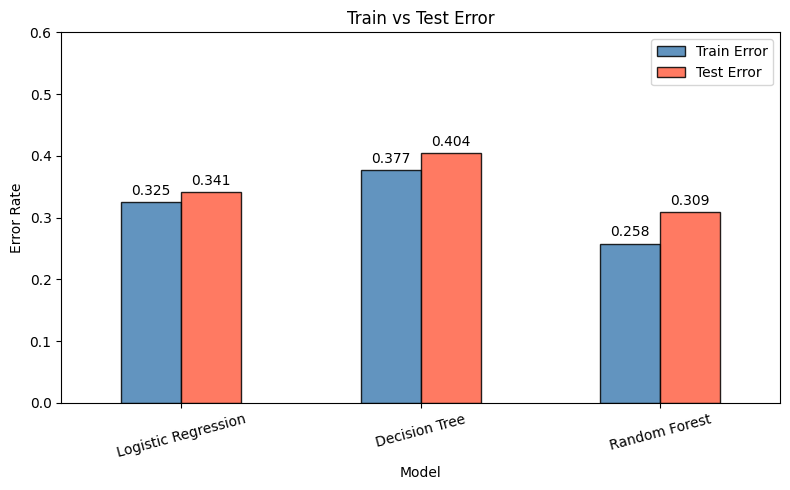

                     Train Error  Test Error
Model                                       
Logistic Regression       0.3251      0.3408
Decision Tree             0.3773      0.4045
Random Forest             0.2578      0.3090


In [25]:
# large gap between train and test error indicates overfitting
# train vs test error to check for overfitting
error_data = []
for name, model in models.items():
    error_data.append({
        'Model': name,
        'Train Error': 1 - accuracy_score(y_train, model.predict(X_train_scaled)),
        'Test Error':  1 - accuracy_score(y_test,  model.predict(X_test_scaled))
    })

err_df = pd.DataFrame(error_data).set_index('Model')
ax = err_df.plot(kind='bar', figsize=(8,5), color=['steelblue','tomato'],
    edgecolor='black', alpha=0.85)
ax.set_title('Train vs Test Error')
ax.set_ylabel('Error Rate')
ax.set_ylim(0, 0.6)
ax.tick_params(axis='x', rotation=15)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=3)
plt.tight_layout()
plt.savefig('error_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(err_df.round(4))

In [26]:
# false negatives are the most critical error in medical screening
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

test_results = X_test.copy()
test_results['TrueLabel'] = y_test.values
test_results['Predicted'] = y_pred_best
test_results['CHD_Prob']  = y_prob_best.round(3)

true_pos  = test_results[(test_results['TrueLabel']==1)&(test_results['Predicted']==1)]
false_neg = test_results[(test_results['TrueLabel']==1)&(test_results['Predicted']==0)]
false_pos = test_results[(test_results['TrueLabel']==0)&(test_results['Predicted']==1)]

display_cols = ['age','male','sysBP','glucose','BMI','totChol','TrueLabel','Predicted','CHD_Prob']
print(f'Model: {best_model_name}')
print(f'True Positives: {len(true_pos)} | False Negatives: {len(false_neg)} | False Positives: {len(false_pos)}')
print('\n--- Correctly Detected CHD Patients ---')
print(true_pos[display_cols].head(5).to_string(index=False))
print('\n--- Missed CHD Patients ---')
print(false_neg[display_cols].head(5).to_string(index=False))
print('\n--- Healthy Patients Misclassified as CHD ---')
print(false_pos[display_cols].head(5).to_string(index=False))

Model: Logistic Regression
True Positives: 76 | False Negatives: 53 | False Positives: 236

--- Correctly Detected CHD Patients ---
 age  male  sysBP  glucose   BMI  totChol  TrueLabel  Predicted  CHD_Prob
49.0   1.0  150.0     74.0 27.92    247.0          1          1     0.583
67.0   0.0  101.0     85.0 23.10    281.0          1          1     0.537
67.0   1.0  127.5     84.0 22.11    214.0          1          1     0.683
62.0   0.0  166.0     78.0 31.44    174.0          1          1     0.645
64.0   1.0  142.0     83.0 27.01    296.0          1          1     0.714

--- Missed CHD Patients ---
 age  male  sysBP  glucose   BMI  totChol  TrueLabel  Predicted  CHD_Prob
42.0   0.0  126.0     65.0 22.65    219.0          1          0     0.267
45.0   1.0  129.0     65.0 27.11    241.0          1          0     0.434
45.0   0.0  116.0     55.0 23.85    285.0          1          0     0.309
39.0   0.0  137.0     85.0 19.57    190.0          1          0     0.270
38.0   0.0  140.0     70.

## 7. Statistical Tests
5x2 cross-validation to compare model pairs, plus variance analysis across random seeds.

In [27]:
# 5x2 CV gives more reliable model comparison than standard CV
def five_by_two_cv(model_a, model_b, X, y):
    diffs = []
    for seed in range(5):
        skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=seed)
        fold_diffs = []
        for train_idx, val_idx in skf.split(X, y):
            Xtr, Xv = X.iloc[train_idx], X.iloc[val_idx]
            ytr, yv = y.iloc[train_idx], y.iloc[val_idx]
            model_a.fit(Xtr, ytr)
            model_b.fit(Xtr, ytr)
            pa = roc_auc_score(yv, model_a.predict_proba(Xv)[:,1])
            pb = roc_auc_score(yv, model_b.predict_proba(Xv)[:,1])
            fold_diffs.append(pa - pb)
        diffs.append(fold_diffs)
    diffs = np.array(diffs)
    mean_diff = diffs[0].mean()
    variance = np.sum([(d - mean_diff)**2 for row in diffs for d in row]) / 5
    t_stat = mean_diff / (np.sqrt(variance / 5) + 1e-10)
    from scipy.stats import t as t_dist
    p_val = 2 * (1 - t_dist.cdf(abs(t_stat), df=5))
    return t_stat, p_val

print('Running 5x2 CV...')
pairs = [
    ('LR vs DT',
     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced', **lr_cv.best_params_),
     DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced', **dt_cv.best_params_)),
    ('LR vs RF',
     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced', **lr_cv.best_params_),
     RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', **rf_cv.best_params_)),
    ('DT vs RF',
     DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced', **dt_cv.best_params_),
     RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', **rf_cv.best_params_)),
]

stat_results = []
for label, ma, mb in pairs:
    t, p = five_by_two_cv(ma, mb, X_train_scaled, y_train)
    stat_results.append({'Comparison': label, 't-stat': round(t,4),
                         'p-value': round(p,4), 'Significant': p < 0.05})
pd.DataFrame(stat_results)

Running 5x2 CV...


,Comparison,t-stat,p-value,Significant
0,LR vs DT,9.8472,0.0002,True
1,LR vs RF,5.3623,0.0030,True
2,DT vs RF,-4.3798,0.0072,True


In [28]:
# low std across seeds means results are stable
seeds = [0, 7, 21, 42, 99]
best_models_refit = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
        class_weight='balanced', **lr_cv.best_params_),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE,
        class_weight='balanced', **dt_cv.best_params_),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE,
        class_weight='balanced', **rf_cv.best_params_)
}
seed_scores = {name: [] for name in best_models_refit}

for seed in seeds:
    Xtr, Xte, ytr, yte = train_test_split(
        X_imputed, y, test_size=0.2, random_state=seed, stratify=y)
    sc = StandardScaler()
    Xtr_s = Xtr.copy(); Xte_s = Xte.copy()
    Xtr_s[num_cols] = sc.fit_transform(Xtr[num_cols])
    Xte_s[num_cols] = sc.transform(Xte[num_cols])
    for name, model in best_models_refit.items():
        model.fit(Xtr_s, ytr)
        seed_scores[name].append(roc_auc_score(yte, model.predict_proba(Xte_s)[:,1]))

seed_df = pd.DataFrame(seed_scores, index=[f'seed={s}' for s in seeds])
seed_df.loc['mean'] = seed_df.mean()
seed_df.loc['std']  = seed_df.std()
seed_df.round(4)

,Logistic Regression,Decision Tree,Random Forest
seed=0,0.7107,0.6669,0.6983
seed=7,0.7545,0.6845,0.7209
seed=21,0.7189,0.6739,0.6749
seed=42,0.6990,0.6411,0.6815
seed=99,0.7297,0.6724,0.7141
mean,0.7226,0.6677,0.6979
std,0.0189,0.0145,0.0178


## 8. Feature Importance
RF feature importances and LR coefficient magnitudes show which features drive predictions.

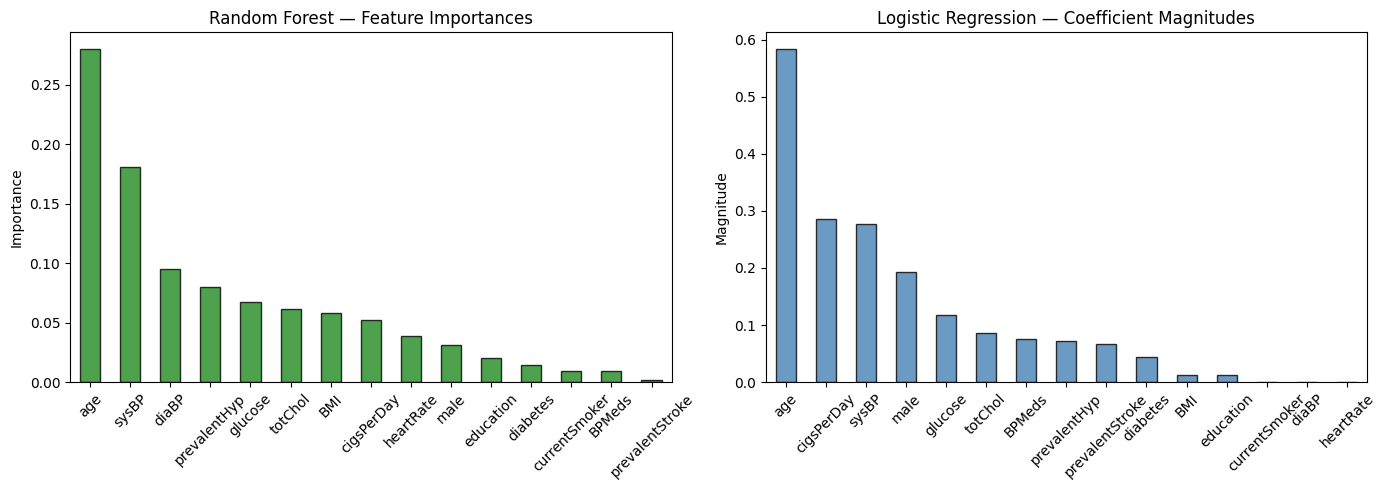

In [29]:
# sysBP, age and glucose are the most important features
rf_importances = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=False)
lr_coefs = pd.Series(np.abs(best_lr.coef_[0]), index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rf_importances.plot(kind='bar', ax=axes[0], color='forestgreen', edgecolor='black', alpha=0.8)
axes[0].set_title('Random Forest — Feature Importances')
axes[0].set_ylabel('Importance')
axes[0].tick_params(axis='x', rotation=45)

lr_coefs.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Logistic Regression — Coefficient Magnitudes')
axes[1].set_ylabel('Magnitude')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

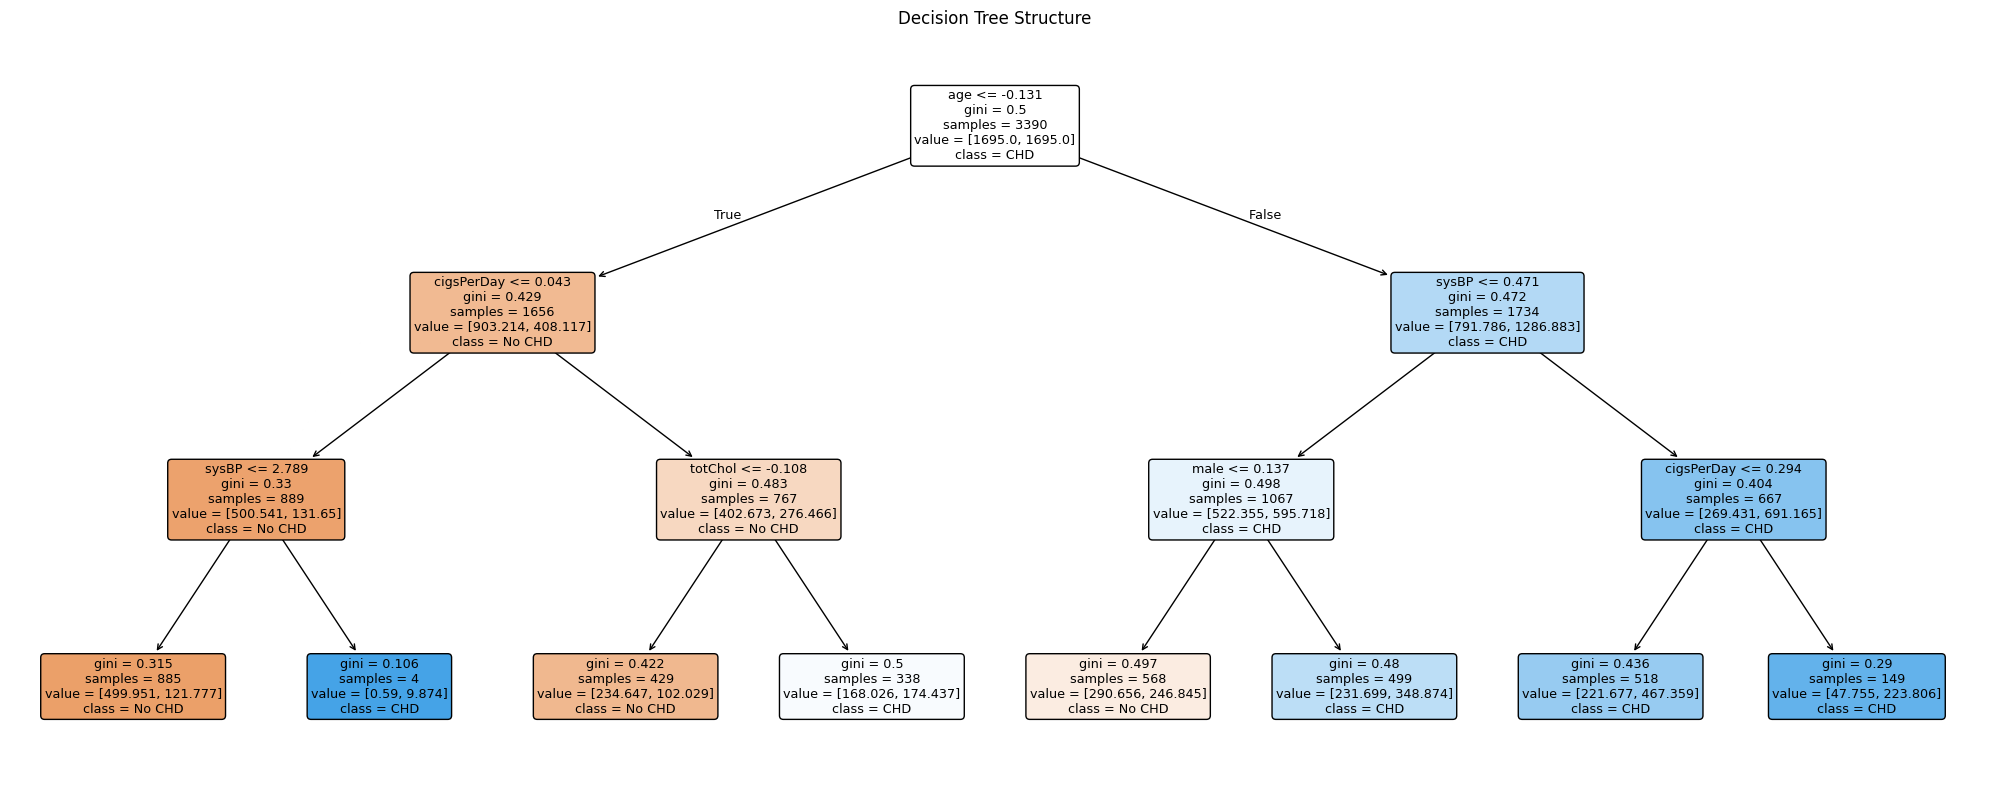

In [30]:
# tree limited to depth 4 for readability
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    best_dt if best_dt.get_depth() <= 4 else
    DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(X_train_scaled, y_train),
    feature_names=feature_names, class_names=['No CHD','CHD'],
    filled=True, rounded=True, ax=ax, max_depth=4
)
ax.set_title('Decision Tree Structure')
plt.tight_layout()
plt.savefig('decision_tree_viz.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Ablation Study
Three sub-experiments: feature group impact, training size effect, and imputation strategy comparison.

In [31]:
# clinical features contribute most to predictive performance
DEMOGRAPHIC = [c for c in ['male','age','education','currentSmoker'] if c in feature_names]
BEHAVIORAL  = [c for c in ['cigsPerDay'] if c in feature_names]
CLINICAL    = [c for c in ['BPMeds','prevalentStroke','prevalentHyp','diabetes',
               'sysBP','diaBP','totChol','BMI','heartRate','glucose'] if c in feature_names]

ablation_configs = {
    'Demographic only':          DEMOGRAPHIC,
    'Demographic + Behavioral':  DEMOGRAPHIC + BEHAVIORAL,
    'All features':              feature_names
}

ablation_rows = []
for config_name, cols in ablation_configs.items():
    for mname, mcls, bparams in [
        ('LR', LogisticRegression, lr_cv.best_params_),
        ('DT', DecisionTreeClassifier, dt_cv.best_params_),
        ('RF', RandomForestClassifier, rf_cv.best_params_)
    ]:
        kwargs = dict(random_state=RANDOM_STATE, class_weight='balanced', **bparams)
        if mname == 'LR': kwargs['max_iter'] = 1000
        m = mcls(**kwargs)
        m.fit(X_train_scaled[cols], y_train)
        prob = m.predict_proba(X_test_scaled[cols])[:,1]
        ablation_rows.append({'Config': config_name, 'Model': mname,
                              'ROC-AUC': round(roc_auc_score(y_test, prob), 4)})

ablation_df = pd.DataFrame(ablation_rows).pivot_table(
    index='Config', columns='Model', values='ROC-AUC'
).reindex(ablation_configs.keys())
ablation_df

Model,DT,LR,RF
Config,,,
Demographic only,0.6421,0.6705,0.6605
Demographic + Behavioral,0.6421,0.6687,0.6624
All features,0.6411,0.6990,0.6815


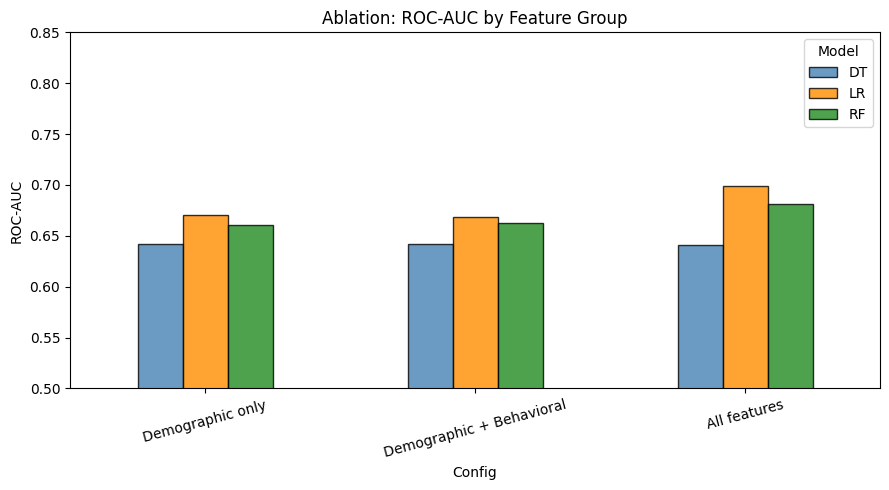

In [32]:
ax = ablation_df.plot(kind='bar', figsize=(9,5),
    color=['steelblue','darkorange','forestgreen'], edgecolor='black', alpha=0.8)
ax.set_title('Ablation: ROC-AUC by Feature Group')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.5, 0.85)
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Model')
plt.tight_layout()
plt.savefig('ablation_features.png', dpi=150, bbox_inches='tight')
plt.show()

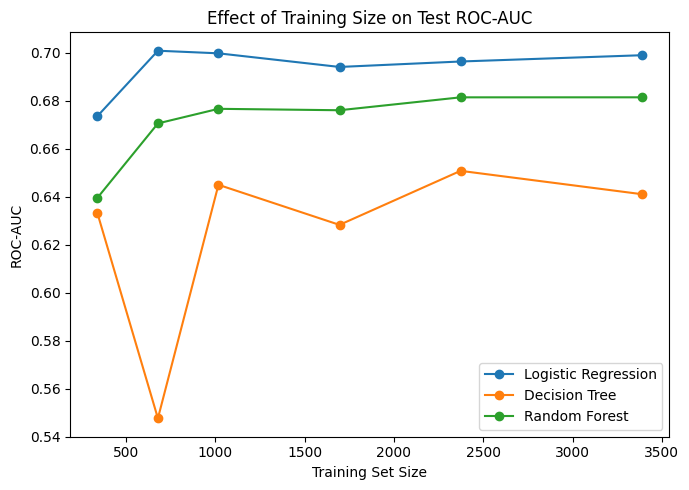

In [33]:
# performance plateaus after using roughly 50% of training data
train_sizes = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
lc_results = {name: [] for name in models}

for frac in train_sizes:
    n = max(10, int(len(X_train_scaled) * frac))
    for name, model in models.items():
        model.fit(X_train_scaled.iloc[:n], y_train.iloc[:n])
        prob = model.predict_proba(X_test_scaled)[:,1]
        lc_results[name].append(roc_auc_score(y_test, prob))

plt.figure(figsize=(7, 5))
for name, scores in lc_results.items():
    plt.plot([int(len(X_train_scaled)*f) for f in train_sizes],
             scores, marker='o', label=name)
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC')
plt.title('Effect of Training Size on Test ROC-AUC')
plt.legend()
plt.tight_layout()
plt.savefig('ablation_train_size.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# listwise deletion performs slightly better here
# likely because missing values are not completely at random
Xlw_tr, Xlw_te, ylw_tr, ylw_te = train_test_split(
    X_listwise, y_listwise, test_size=0.2, random_state=RANDOM_STATE, stratify=y_listwise)
sc2 = StandardScaler()
Xlw_tr_s = Xlw_tr.copy(); Xlw_te_s = Xlw_te.copy()
Xlw_tr_s[num_cols] = sc2.fit_transform(Xlw_tr[num_cols])
Xlw_te_s[num_cols] = sc2.transform(Xlw_te[num_cols])

imp_rows = []
for name, model in models.items():
    auc_imp = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])
    model.fit(Xlw_tr_s, ylw_tr)
    auc_lw = roc_auc_score(ylw_te, model.predict_proba(Xlw_te_s)[:,1])
    imp_rows.append({'Model': name,
                    'Median Imputation': round(auc_imp, 4),
                    'Listwise Deletion': round(auc_lw, 4)})
pd.DataFrame(imp_rows).set_index('Model')

,Median Imputation,Listwise Deletion
Model,,
Logistic Regression,0.6990,0.7338
Decision Tree,0.6411,0.6732
Random Forest,0.6815,0.7079


## 10. Timing & Final Summary

In [35]:
# LR is fastest, RF takes longest due to many trees
timing_df = pd.DataFrame({
    'Model': list(models.keys()),
    'Train Time (s)': [round(train_times[n], 3) for n in models],
    'Inference Time (ms)': [round(inference_times[n], 3) for n in models]
}).set_index('Model')
print('=== Timing ===')
print(timing_df)

=== Timing ===
                     Train Time (s)  Inference Time (ms)
Model                                                   
Logistic Regression           2.378                1.448
Decision Tree                 0.420                0.466
Random Forest                 5.573                9.449


In [36]:
# LR achieves best ROC-AUC and is most stable across seeds
print('=== Final Results ===')
print(results_df.round(4).to_string())
best = results_df['ROC-AUC'].idxmax()
print(f'\nBest model: {best} — ROC-AUC: {results_df.loc[best, "ROC-AUC"]:.4f}')

=== Final Results ===
                     Accuracy  Precision  Recall      F1  ROC-AUC  Train Time (s)  Inference Time (ms)
Model                                                                                                 
Logistic Regression    0.6592     0.2436  0.5891  0.3447   0.6990            2.38                 1.45
Decision Tree          0.5955     0.2139  0.6202  0.3181   0.6411            0.42                 0.47
Random Forest          0.6910     0.2432  0.4884  0.3247   0.6815            5.57                 9.45

Best model: Logistic Regression — ROC-AUC: 0.6990
